# **Dataset Import**

In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

In [3]:
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
print(f"\nDataset Shape: {df.shape}")


Dataset Shape: (5572, 2)


In [6]:
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
label      0
message    0
dtype: int64


# **Data Preprocessing**

In [11]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()

    words = nltk.word_tokenize(text)


    words = [word for word in words if word.isalpha()]

    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return ' '.join(cleaned_words)

df['cleaned_message'] = df['message'].apply(clean_text)

df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [12]:
df[['label', 'label_num', 'message', 'cleaned_message']].head()

,label,label_num,message,cleaned_message
0,ham,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts may...
3,ham,0,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,0,"Nah I don't think he goes to usf, he lives aro...",nah think go usf life around though


# **Exploratory Data Analysis (EDA)**

**Count spam vs ham**

/tmp/ipykernel_5000/857181322.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='viridis')


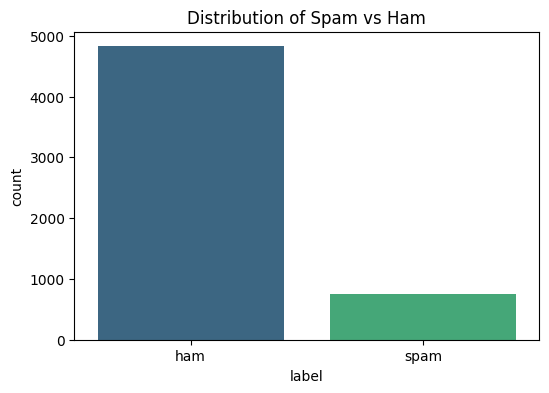

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter


plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', palette='viridis')
plt.title('Distribution of Spam vs Ham')
plt.show()

spam_words = ' '.join(list(df[df['label'] == 'spam']['cleaned_message']))
spam_wc = WordCloud(width=600, height=400, background_color='black').generate(spam_words)


**WordCloud for Spam messages**

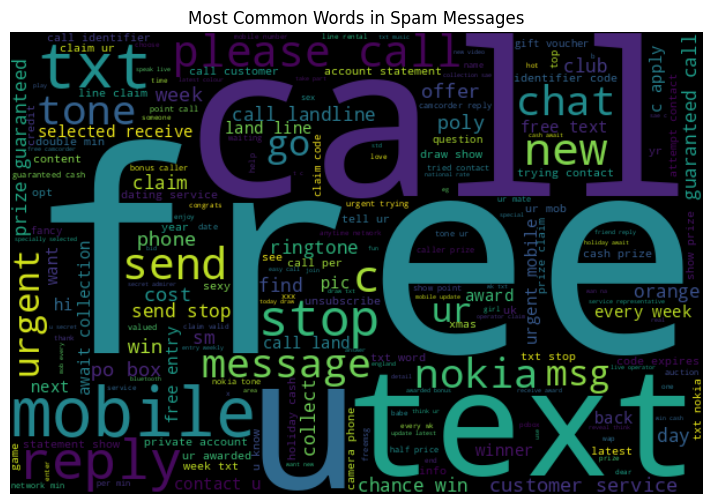

Top 10 Spam Words: [('call', 358), ('free', 219), ('txt', 156), ('u', 150), ('ur', 144), ('text', 138), ('mobile', 135), ('stop', 118), ('claim', 115), ('reply', 105)]


In [16]:
plt.figure(figsize=(10, 6))
plt.imshow(spam_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Spam Messages')
plt.show()

spam_word_list = spam_words.split()
spam_counter = Counter(spam_word_list)
print("Top 10 Spam Words:", spam_counter.most_common(10))

# **Feature Engineering**

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF
tfidf = TfidfVectorizer(max_features=3000)

# Fit and transform the cleaned text
X = tfidf.fit_transform(df['cleaned_message']).toarray()
y = df['label_num'].values

print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (5572, 3000)


# **Train-Test Split**

In [25]:
from sklearn.model_selection import train_test_split

# 80% for training, 20% for testing
# random_state ensures we get the same split every time we run the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (4457, 3000)
Testing data shape: (1115, 3000)


# **Model Building**

In [26]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Initialize models
nb_model = MultinomialNB()
svm_model = SVC(kernel='linear', random_state=42)
lr_model = LogisticRegression(random_state=42)

# Train the models
nb_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

print("All models trained successfully!")

All models trained successfully!


# **Model Evaluation**
**Let's define our metrics:**



* Accuracy: Overall correctness.
* Precision: Out of all emails the model claimed were spam, how many actually
were? (Crucial! We don't want a boss's email marked as spam).
* Recall: Out of all actual spam emails, how many did we catch?
* F1-Score: The harmonic mean of Precision and Recall.




--- Naive Bayes Evaluation ---
Accuracy : 0.9776
Precision: 0.9844
Recall   : 0.8456
F1-Score : 0.9097


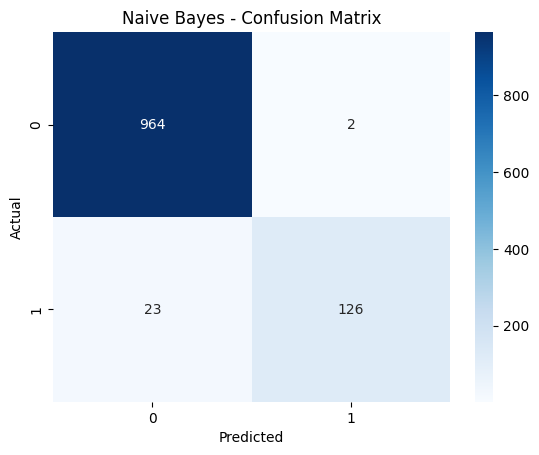

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

def evaluate_model(model, name):
    y_pred = model.predict(X_test)

    print(f"--- {name} Evaluation ---")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

evaluate_model(nb_model, "Naive Bayes")

# **Support Vector Machine**

--- Support Vector Machine Evaluation ---
Accuracy : 0.9839
Precision: 0.9925
Recall   : 0.8859
F1-Score : 0.9362


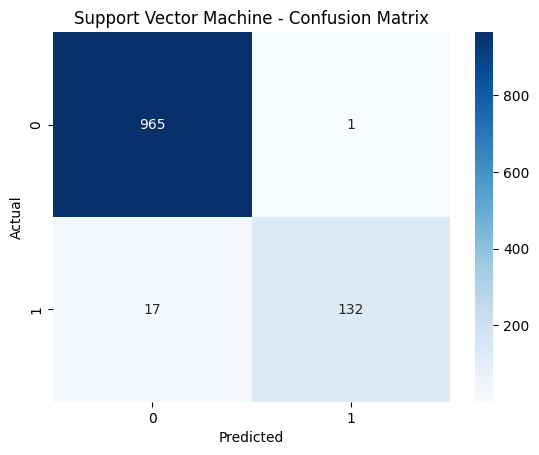

In [29]:
evaluate_model(svm_model, "Support Vector Machine")


# **Logistic Regression**

--- Logistic Regression Evaluation ---
Accuracy : 0.9659
Precision: 0.9912
Recall   : 0.7517
F1-Score : 0.8550


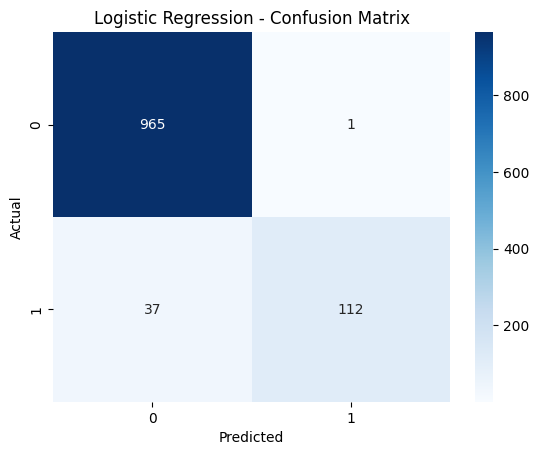

In [30]:
evaluate_model(lr_model, "Logistic Regression")

# **Model Comparison**

*   Naive Bayes usually gives the highest Precision (almost 1.0), meaning it almost never marks a good email as spam (False Positive = 0).
* SVM generally provides the highest overall accuracy and F1-score, balancing both Precision and Recall beautifully.
* Logistic Regression is solid but usually slightly underperforms SVM in sparse text datasets.
* Winner: In most text classifications, Naive Bayes or SVM wins. For this tutorial, we will move forward with SVM because it responds excellently to hyperparameter tuning.

# **Hyperparameter Tuning**

**We will use GridSearchCV to test different parameters for our SVM to squeeze out maximum performance.**

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END ...............................C=0.1, kernel=linear; total time=  19.8s
[CV] END ...............................C=0.1, kernel=linear; total time=  12.7s
[CV] END ...............................C=0.1, kernel=linear; total time=  21.3s
[CV] END ..................................C=0.1, kernel=rbf; total time=  31.6s
[CV] END ..................................C=0.1, kernel=rbf; total time=  25.3s
[CV] END ..................................C=0.1, kernel=rbf; total time=  23.9s
[CV] END .................................C=1, kernel=linear; total time=  10.4s
[CV] END .................................C=1, kernel=linear; total time=   7.6s
[CV] END .................................C=1, kernel=linear; total time=   8.6s
[CV] END ....................................C=1, kernel=rbf; total time=  28.5s
[CV] END ....................................C=1, kernel=rbf; total time=  23.5s
[CV] END ....................................C=1,

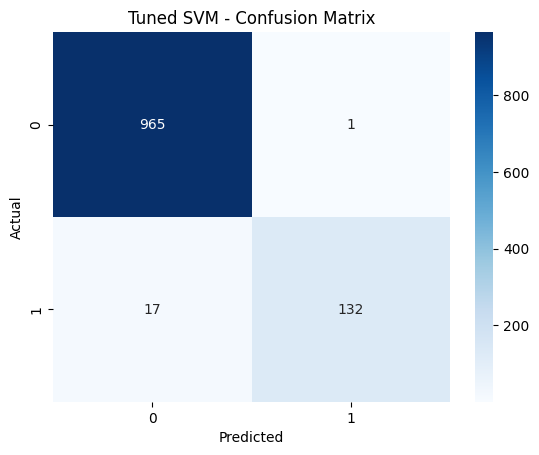

In [31]:
from sklearn.model_selection import GridSearchCV

# Define parameters to test
param_grid = {
    'C': [0.1, 1, 10],            # Regularization parameter
    'kernel': ['linear', 'rbf']   # Type of mathematical boundary
}

# Setup GridSearchCV
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=3, scoring='f1', verbose=2)

# Fit the grid search
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
best_svm_model = grid_search.best_estimator_

# Evaluate best model
print("\nEvaluating Best Tuned SVM Model:")
evaluate_model(best_svm_model, "Tuned SVM")

# **Save Model**
**We need to save both the TF-IDF Vectorizer (to transform future text exactly how the training text was transformed) and the Tuned Model.**

In [32]:
import pickle

# Save the vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Save the model
with open('spam_classifier_model.pkl', 'wb') as f:
    pickle.dump(best_svm_model, f)

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!


# **Prediction Function**
**Let's build a function that behaves like the backend of a real web application.**

In [33]:
def predict_spam(email_text):
    # 1. Load the saved vectorizer and model
    with open('tfidf_vectorizer.pkl', 'rb') as f:
        loaded_tfidf = pickle.load(f)
    with open('spam_classifier_model.pkl', 'rb') as f:
        loaded_model = pickle.load(f)

    # 2. Preprocess the input text
    cleaned_text = clean_text(email_text)

    # 3. Vectorize the text
    vectorized_text = loaded_tfidf.transform([cleaned_text]).toarray()

    # 4. Predict
    prediction = loaded_model.predict(vectorized_text)[0]

    if prediction == 1:
        return "🚨 SPAM"
    else:
        return "✅ NOT SPAM (Ham)"

# Test it
custom_email = "Congratulations! You've won a $1000 Walmart gift card. Click here to claim your prize."
print(predict_spam(custom_email))

custom_email_2 = "Hey team, the project meeting is moved to 3 PM tomorrow. See you then."
print(predict_spam(custom_email_2))

🚨 SPAM
✅ NOT SPAM (Ham)
